In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # For progress bars in Jupyter
from matplotlib import cm # For advanced colormaps
import cv2 # For image processing and blending
import numpy as np # Import numpy for array operations
import math
import random # For random noise in diffusion

# --- Configuration ---

class Config:
    def __init__(self):
        # Data Paths
        self.data_root_hr = "/home/nachiket/Downloads/Havard-Medical-Image-Fusion-Datasets-Copy/TRIMODAL" # HR Ground Truth
        self.data_root_lr = "/home/nachiket/Downloads/Havard-Medical-Image-Fusion-Datasets-Copy/TRIMODAL-LR" # LR Inputs
        self.t1_dir = "T1-MRI"
        self.t2_dir = "T2-MRI"
        self.pet_dir = "PET"
        self.train_split_ratio = 0.7
        self.val_split_ratio = 0.15
        self.test_split_ratio = 0.15
        self.seed = 42

        # Image Dimensions
        self.image_size_hr = 256 # High-resolution target
        self.image_size_lr = 128 # Low-resolution input
        self.upscale_factor = self.image_size_hr // self.image_size_lr
        self.image_channels_hr = 5 # Fused HR image has 3 channels (T1, T2, PET_avg)

        # Training Parameters
        self.batch_size = 4
        self.num_workers = 4 # Adjust based on your system
        self.num_epochs = 80 # Total epochs for training. Can be reduced for a quick test.
        self.learning_rate = 1e-4
        self.log_interval = 100 # Log loss every X steps
        self.save_interval = 20 # Save model every X epochs
        self.eval_interval = 20 # Evaluate PSNR every N epochs (added for PSNR)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model_save_path = "diffusion_sr_model.pth"

        # TMFA Model Parameters
        self.encoder_channels = 32 # Channels for initial convolution in modality encoders
        self.reduction_ratio = 16 # Reduction ratio for SE block FC layers in TMFA
        self.conditional_channels = 64 # Output channels of TMFA, input to U-Net as conditioning

        # DDPM U-Net Parameters
        self.base_channels = 64 # Base channels for U-Net's first layer
        self.channel_multipliers = [1, 2, 4, 8] # Multipliers for U-Net channels at different resolutions
        self.num_res_blocks = 2 # Number of ResNet blocks per U-Net level
        self.attn_resolutions = [32, 16] # Resolutions at which to apply AttentionBlock (e.g., 32x32, 16x16). Note: max res is 256, so 64, 32, 16, 8. Adjusted for example to 32, 16.
        
        # Diffusion Process Parameters
        self.timesteps = 1000 # Number of diffusion steps
        self.beta_schedule = 'linear' # 'linear', 'cosine'
        self.start_beta = 0.0001
        self.end_beta = 0.02
        self.loss_type = 'l1' # 'l1', 'l2', 'huber'

cfg = Config()
print(f"Using device: {cfg.device}")

In [ ]:
# --- Define the create_t1_t2_pet_fusion_display_rgb function here ---
# This function was previously discussed and is needed for the sample display
def create_t1_t2_pet_fusion_display_rgb(t1_np_grayscale, t2_np_grayscale, pet_np_rgb, 
                                        mri_blend_weight_t1=0.7, pet_alpha=0.5):
    """
    Creates a fusion image from grayscale T1, grayscale T2, and RGB PET,
    retaining grayscale for MRIs and original RGB for PET.

    Fusion Strategy:
    1. Create a base MRI image by blending T1 and T2 (resulting in grayscale).
    2. Convert this grayscale MRI base into a 3-channel RGB image (where R=G=B).
    3. Directly overlay the original RGB PET onto this 3-channel grayscale MRI base.
    
    Args:
        t1_np_grayscale (np.ndarray): Grayscale T1 image (H, W) or (H, W, 1), in [0, 1].
        t2_np_grayscale (np.ndarray): Grayscale T2 image (H, W) or (H, W, 1), in [0, 1].
        pet_np_rgb (np.ndarray): PET RGB image (H, W, 3), in [0, 1]. This must be 3-channel RGB.
                                 (Ensure this is truly the original RGB PET data if you want to preserve its colors).
        mri_blend_weight_t1 (float): Weight for T1 when blending with T2 (0.0 to 1.0).
                                     (1 - mri_blend_weight_t1) is the weight for T2.
        pet_alpha (float): Transparency of the PET overlay (0.0 to 1.0).

    Returns:
        np.ndarray: The fused image as a NumPy array (H, W, 3) in RGB format, [0, 1] float.
    """
    # Ensure MRI inputs are 2D grayscale
    if t1_np_grayscale.ndim == 3 and t1_np_grayscale.shape[2] == 1:
        t1_np_grayscale = t1_np_grayscale[:,:,0]
    if t2_np_grayscale.ndim == 3 and t2_np_grayscale.shape[2] == 1:
        t2_np_grayscale = t2_np_grayscale[:,:,0]
        
    # Ensure PET input is 3D RGB
    if not (pet_np_rgb.ndim == 3 and pet_np_rgb.shape[2] == 3):
        raise ValueError("pet_np_rgb must be a 3-channel (H, W, 3) image for this fusion strategy to preserve RGB PET.")


    # 1. Create a blended MRI base (T1 and T2) in grayscale
    mri_base_grayscale = (t1_np_grayscale * mri_blend_weight_t1 + 
                          t2_np_grayscale * (1 - mri_blend_weight_t1)).clip(0, 1)

    # 2. Convert grayscale MRI base to 3-channel RGB (R=G=B)
    mri_base_rgb = np.stack([mri_base_grayscale, mri_base_grayscale, mri_base_grayscale], axis=-1)

    # 3. Directly overlay the original RGB PET onto the 3-channel grayscale MRI base
    # Use cv2.addWeighted for blending (expects 0-255 uint8, BGR)
    mri_base_bgr_uint8 = (mri_base_rgb * 255).astype(np.uint8)[:, :, ::-1] # RGB to BGR
    pet_original_bgr_uint8 = (pet_np_rgb * 255).astype(np.uint8)[:, :, ::-1] # Original PET RGB to BGR

    fused_bgr_image_uint8 = cv2.addWeighted(mri_base_bgr_uint8, 1 - pet_alpha, pet_original_bgr_uint8, pet_alpha, 0)
    
    # Convert back to RGB float [0, 1] for Matplotlib display
    fused_rgb_image_float = fused_bgr_image_uint8[:, :, ::-1].astype(np.float32) / 255.0

    return fused_rgb_image_float

class TrimodalMedicalDataset(Dataset):
    def __init__(self, cfg, filenames=None): # Modified to accept a list of filenames
        self.cfg = cfg

        # Paths for HR Ground Truth images
        self.t1_hr_path = os.path.join(cfg.data_root_hr, cfg.t1_dir)
        self.t2_hr_path = os.path.join(cfg.data_root_hr, cfg.t2_dir)
        self.pet_hr_path = os.path.join(cfg.data_root_hr, cfg.pet_dir)

        # Paths for LR Input images
        self.t1_lr_path = os.path.join(cfg.data_root_lr, cfg.t1_dir)
        self.t2_lr_path = os.path.join(cfg.data_root_lr, cfg.t2_dir)
        self.pet_lr_path = os.path.join(cfg.data_root_lr, cfg.pet_dir)

        # If filenames are provided (for train/val/test splits), use them directly
        if filenames is not None:
            self.filenames = filenames
        else: # Otherwise, find all common filenames (for the initial full dataset)
            t1_hr_files = {f for f in os.listdir(self.t1_hr_path) if f.endswith('.png')}
            t2_hr_files = {f for f in os.listdir(self.t2_hr_path) if f.endswith('.png')}
            pet_hr_files = {f for f in os.listdir(self.pet_hr_path) if f.endswith('.png')}

            t1_lr_files = {f for f in os.listdir(self.t1_lr_path) if f.endswith('.png')}
            t2_lr_files = {f for f in os.listdir(self.t2_lr_path) if f.endswith('.png')}
            pet_lr_files = {f for f in os.listdir(self.pet_lr_path) if f.endswith('.png')}

            self.filenames = sorted(list(
                t1_hr_files.intersection(t2_hr_files).intersection(pet_hr_files)
                .intersection(t1_lr_files).intersection(t2_lr_files).intersection(pet_lr_files)
            ))

        if not self.filenames:
            raise RuntimeError("No common .png files found across HR and LR datasets after splitting (or initially).")

        print(f"Dataset initialized with {len(self.filenames)} samples.")

        # Define transforms
        self.grayscale_transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
        ])
        self.rgb_transform = transforms.Compose([
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]

        # --- Load HR images ---
        t1_img_hr = Image.open(os.path.join(self.t1_hr_path, filename)).convert('L')
        t2_img_hr = Image.open(os.path.join(self.t2_hr_path, filename)).convert('L')
        pet_img_hr = Image.open(os.path.join(self.pet_hr_path, filename)).convert('RGB')

        t1_hr = self.grayscale_transform(t1_img_hr)  # (1,H,W)
        t2_hr = self.grayscale_transform(t2_img_hr)  # (1,H,W)
        pet_hr = self.rgb_transform(pet_img_hr)      # (3,H,W)

        # --- Load LR images ---
        t1_img_lr = Image.open(os.path.join(self.t1_lr_path, filename)).convert('L')
        t2_img_lr = Image.open(os.path.join(self.t2_lr_path, filename)).convert('L')
        pet_img_lr = Image.open(os.path.join(self.pet_lr_path, filename)).convert('RGB')

        t1_lr = self.grayscale_transform(t1_img_lr)  # (1,H,W)
        t2_lr = self.grayscale_transform(t2_img_lr)  # (1,H,W)
        pet_lr = self.rgb_transform(pet_img_lr)      # (3,H,W)

        # --- Fused HR for training: keep all modality channels ---
        gt_hr_fused = torch.cat([t1_hr, t2_hr, pet_hr], dim=0)  # (5,H,W)

        # --- Visualization version: overlay PET color on T1 (no change needed here) ---
        t1_rgb = t1_hr.repeat(3, 1, 1)  # grayscale → RGB
        fused_vis = (0.6 * t1_rgb + 0.4 * pet_hr).clamp(0, 1)

        # --- Normalize all inputs to [-1, 1] ---
        normalize = lambda x: (x * 2) - 1
        t1_lr, t2_lr, pet_lr, gt_hr_fused = map(normalize, [t1_lr, t2_lr, pet_lr, gt_hr_fused])

        return {
            't1_lr': t1_lr,          # (1,H,W)
            't2_lr': t2_lr,          # (1,H,W)
            'pet_lr': pet_lr,        # (3,H,W)
            'gt_hr': gt_hr_fused,    # (5,H,W)
            'vis_fused': fused_vis,  # (3,H,W), for visualization only
            'filename': filename     # Include filename for potential debugging/tracking
        }
# --- Data Loading and Splitting ---
print("Initializing full dataset to gather all filenames...")
try:
    # First, create a temporary dataset instance to get all filenames
    # This instance will not be used directly for training, only for its list of filenames
    full_dataset_temp = TrimodalMedicalDataset(cfg, filenames=None) 
    all_filenames = full_dataset_temp.filenames
    total_samples = len(all_filenames)

    # Calculate split sizes
    train_size = int(cfg.train_split_ratio * total_samples)
    val_size = int(cfg.val_split_ratio * total_samples)
    test_size = total_samples - train_size - val_size # Ensure all samples are used

    # Ensure sizes are positive
    if not (train_size > 0 and val_size > 0 and test_size > 0):
        raise ValueError(f"Calculated split sizes are too small: Train={train_size}, Val={val_size}, Test={test_size}. Adjust split ratios or ensure enough data.")

    # Split the filenames
    rng = torch.Generator().manual_seed(cfg.seed) # For reproducible splits
    shuffled_filenames = np.random.RandomState(seed=cfg.seed).permutation(all_filenames).tolist()

    train_filenames = shuffled_filenames[:train_size]
    val_filenames = shuffled_filenames[train_size : train_size + val_size]
    test_filenames = shuffled_filenames[train_size + val_size :]

    print(f"Total samples: {total_samples}")
    print(f"Train samples: {len(train_filenames)} ({cfg.train_split_ratio*100:.0f}%)")
    print(f"Validation samples: {len(val_filenames)} ({cfg.val_split_ratio*100:.0f}%)")
    print(f"Test samples: {len(test_filenames)} ({cfg.test_split_ratio*100:.0f}%)")

    # Create separate Dataset instances using the split filenames
    train_dataset = TrimodalMedicalDataset(cfg, filenames=train_filenames)
    val_dataset = TrimodalMedicalDataset(cfg, filenames=val_filenames)
    test_dataset = TrimodalMedicalDataset(cfg, filenames=test_filenames)

    # Create DataLoaders
    train_dataloader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=cfg.num_workers, pin_memory=True) # Batch size 1 for validation metrics
    test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=cfg.num_workers, pin_memory=True) # Batch size 1 for testing metrics

    print("\nDataLoaders created:")
    print(f"  Training DataLoader: {len(train_dataloader)} batches (Total samples: {len(train_dataset)})")
    print(f"  Validation DataLoader: {len(val_dataloader)} batches (Total samples: {len(val_dataset)})")
    print(f"  Test DataLoader: {len(test_dataloader)} batches (Total samples: {len(test_dataset)})")

    # --- Fetch and Display a Sample from the TRAINING DataLoader (for visual check) ---
    sample = next(iter(train_dataloader))
    print("\nSample Batch Shapes from Training DataLoader:")
    for k, v in sample.items():
        if isinstance(v, torch.Tensor):
            print(f"{k}: {v.shape}, Min: {v.min():.2f}, Max: {v.max():.2f}")
        else:
            print(f"{k}: {v}") # For filename

    # Denormalize for display (your existing function, ensure it's defined earlier)
    def denormalize_img(tensor):
        return ((tensor + 1) / 2).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Sample Data (Batch 0) from Training Set", fontsize=16)

    # Assuming batch_size > 0
    if sample['t1_lr'].shape[0] > 0:
        axes[0, 0].imshow(denormalize_img(sample['t1_lr'][0, 0].unsqueeze(0)), cmap='gray')
        axes[0, 0].set_title(f"T1-LR ({cfg.image_size_lr})")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(denormalize_img(sample['t2_lr'][0, 0].unsqueeze(0)), cmap='gray')
        axes[0, 1].set_title(f"T2-LR ({cfg.image_size_lr})")
        axes[0, 1].axis('off')

        axes[0, 2].imshow(denormalize_img(sample['pet_lr'][0]))
        axes[0, 2].set_title(f"PET-LR ({cfg.image_size_lr})")
        axes[0, 2].axis('off')

        # For fused HR GT, we typically don't display 'vis_fused' but the actual components.
        # Let's show T1-HR from the GT and a fused visualization if desired
        
        # Denormalize individual HR components for the fusion function
        # NOTE: denormalize_img returns (H,W,C) for multi-channel, but the fusion func
        # expects (H,W) for grayscale and (H,W,3) for RGB.
        # So we need to carefully extract the 2D grayscale T1/T2 from the HR GT channels.
        
        # First, denormalize the full HR GT tensor
        # This function is designed for (C,H,W) input, so we give it one sample (0)
        # and then extract channels
        hr_gt_denormalized = ((sample['gt_hr'][0] + 1) / 2).clamp(0, 1).cpu().numpy() # (5, H, W)
        
        gt_t1_hr_display = hr_gt_denormalized[0, :, :] # (H, W)
        gt_t2_hr_display = hr_gt_denormalized[1, :, :] # (H, W)
        gt_pet_hr_rgb_display = hr_gt_denormalized[2:5, :, :].transpose(1, 2, 0) # (3, H, W) -> (H, W, 3)

        fused_gt_hr_display = create_t1_t2_pet_fusion_display_rgb(
            gt_t1_hr_display, # Pass 2D grayscale T1
            gt_t2_hr_display, # Pass 2D grayscale T2
            gt_pet_hr_rgb_display,   # Pass 3D RGB PET
            mri_blend_weight_t1=0.7,
            pet_alpha=0.6
        )
        axes[0, 3].imshow(fused_gt_hr_display)
        axes[0, 3].set_title(f"Fused HR GT ({cfg.image_size_hr})")
        axes[0, 3].axis('off')


    for i in range(4):
        axes[1, i].text(0.5, 0.5, 'Future Super-Resolution Output', ha='center', va='center', transform=axes[1, i].transAxes)
        axes[1, i].axis('off')
        plt.tight_layout(rect=(0.0, 0.03, 1.0, 0.95))
        plt.show()

except RuntimeError as e:
    print(f"Error during dataset initialization or sampling: {e}")
    print("Please check dataset folder structure, filenames, and split ratios.")

In [ ]:
# --- ASFE-Fusion Implementation (Replacing TMFA) ---

# This is a simplified version of the ASFE block, capturing the core idea
# from the ASFE-Fusion paper. The paper's full implementation can be complex
# with multiple branches and specific pooling/conv layers.
# This implementation focuses on the adaptive channel and spatial attention.
class ASFE_Block(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, kernel_size=3):
        super().__init__()
        self.in_channels = in_channels
        self.reduction_ratio = reduction_ratio

        # Channel Attention (similar to SE-Block, but adaptive)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # Shared MLP for channel attention
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction_ratio, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, kernel_size=1, bias=False)
        )

        # Spatial Attention (similar to CBAM)
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=kernel_size, stride=1, padding=kernel_size//2, bias=False)
        self.sigmoid_spatial = nn.Sigmoid() # Reusing this for simplicity

        # Adaptive Gating Mechanism (simplified from paper, using concat and conv to learn weights)
        self.gate_conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, in_channels, kernel_size=1, bias=False), # Input is original features + attention-weighted features
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, 2, kernel_size=1, bias=False), # Output 2 channels for weighting
            nn.Sigmoid() # To get weights between 0 and 1
        )
        self.gamma = nn.Parameter(torch.zeros(1)) # Learnable parameter to weight residual connection

    def forward(self, x):
        # Residual input for the block
        identity = x

        # Channel Attention
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        # Note: The paper uses a sigmoid AFTER the sum for Channel Attention.
        # Your current `self.sigmoid_spatial` is meant for spatial, let's make it more explicit.
        # Let's use a standard sigmoid for channel attention as well.
        channel_attention_map = torch.sigmoid(avg_out + max_out) 

        # Apply channel attention
        x_ca = x * channel_attention_map.expand_as(x)

        # Spatial Attention
        # Aggregate features along channel dimension
        avg_out_spatial = torch.mean(x_ca, dim=1, keepdim=True)
        max_out_spatial, _ = torch.max(x_ca, dim=1, keepdim=True)
        spatial_features = torch.cat([avg_out_spatial, max_out_spatial], dim=1)
        spatial_attention_map = self.sigmoid_spatial(self.conv_spatial(spatial_features)) # Reuse sigmoid for spatial

        # Apply spatial attention
        x_sa = x_ca * spatial_attention_map

        # Adaptive Gating
        combined_features_for_gate = torch.cat([identity, x_sa], dim=1) # Use original input 'identity' and enhanced 'x_sa'
        gate_weights = self.gate_conv(combined_features_for_gate) # (B, 2, H, W)
        
        w1 = gate_weights[:, 0:1, :, :] # Weight for original feature x
        w2 = gate_weights[:, 1:2, :, :] # Weight for attention-enhanced feature x_sa
        
        # Fused output: adaptive combination
        output = w1 * identity + w2 * x_sa

        # Residual connection for the entire block
        output = output + self.gamma * identity 

        return output


# --- ASFE Fusion Model (replacing TMFA_Model) ---
class ASFE_Fusion_Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # Modality Encoders (can be deeper or more complex if needed)
        self.t1_encoder = nn.Sequential(
            nn.Conv2d(1, cfg.encoder_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(cfg.encoder_channels, cfg.encoder_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )
        self.t2_encoder = nn.Sequential(
            nn.Conv2d(1, cfg.encoder_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(cfg.encoder_channels, cfg.encoder_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pet_encoder = nn.Sequential(
            nn.Conv2d(3, cfg.encoder_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(cfg.encoder_channels, cfg.encoder_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )

        # Initial Cross-Modality Fusion (CMF) - concatenation and convolution
        # Combine features from all encoders
        self.initial_fusion_channels = 3 * cfg.encoder_channels
        self.cmf_conv = nn.Sequential(
            nn.Conv2d(self.initial_fusion_channels, cfg.encoder_channels, kernel_size=1, bias=False), # Reduce channels
            nn.BatchNorm2d(cfg.encoder_channels),
            nn.ReLU(inplace=True)
        )

        # ASFE Block for adaptive feature enhancement
        # The ASFE_Block operates on the combined features.
        self.asfe_block = ASFE_Block(in_channels=cfg.encoder_channels, reduction_ratio=16)

        # Final convolution to adjust output channels to match conditional_channels for DDPM
        self.final_conv = nn.Sequential(
            nn.Conv2d(cfg.encoder_channels, cfg.conditional_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, t1_lr, t2_lr, pet_lr):
        # 1. Encode each modality
        t1_features = self.t1_encoder(t1_lr)
        t2_features = self.t2_encoder(t2_lr)
        pet_features = self.pet_encoder(pet_lr)

        # 2. Initial Cross-Modality Fusion (CMF)
        concatenated_features = torch.cat([t1_features, t2_features, pet_features], dim=1)
        fused_initial_features = self.cmf_conv(concatenated_features)

        # 3. Apply ASFE Block for adaptive feature enhancement
        enhanced_features = self.asfe_block(fused_initial_features)
        
        # 4. Final mapping to conditional_channels
        conditional_features = self.final_conv(enhanced_features)

        # --- Defensive check for extra dims ---
        # This check is more robust, as .squeeze(2) might remove a correct dimension if it's there
        if conditional_features.ndim == 5 and conditional_features.shape[2] == 1:
            conditional_features = conditional_features.squeeze(2)
        assert conditional_features.ndim == 4, f"ASFE-Fusion output must be 4D, got {conditional_features.shape}"

        return conditional_features

# --- Test ASFE Fusion Model ---

print("\nInitializing ASFE_Fusion_Model...")
try:
    # Use your actual cfg here
    # If 'cfg' is not already globally available from your setup, define it.
    # The DummyConfig above will serve as a placeholder for testing.
    # Make sure your actual cfg matches the structure.

    asfe_fusion_model = ASFE_Fusion_Model(cfg).to(cfg.device)
    print(f"ASFE-Fusion Model Total Parameters: {sum(p.numel() for p in asfe_fusion_model.parameters()):,}")

    # Use a sample from the dataloader to test the ASFE-Fusion model
    # The 'train_dataloader' should be available from the previous cell's execution.
    if 'train_dataloader' in locals() and train_dataloader is not None:
        sample_batch = next(iter(train_dataloader))
        t1_lr_batch = sample_batch['t1_lr'].to(cfg.device)
        t2_lr_batch = sample_batch['t2_lr'].to(cfg.device)
        pet_lr_batch = sample_batch['pet_lr'].to(cfg.device)
    else:
        print("Train Dataloader not found, creating dummy input tensors for testing.")
        t1_lr_batch = torch.randn(cfg.batch_size, 1, cfg.image_size_lr, cfg.image_size_lr).to(cfg.device)
        t2_lr_batch = torch.randn(cfg.batch_size, 1, cfg.image_size_lr, cfg.image_size_lr).to(cfg.device)
        pet_lr_batch = torch.randn(cfg.batch_size, 3, cfg.image_size_lr, cfg.image_size_lr).to(cfg.device)


    with torch.no_grad():
        asfe_output = asfe_fusion_model(t1_lr_batch, t2_lr_batch, pet_lr_batch)

    print(f"\nASFE-Fusion Model Output Shape: {asfe_output.shape}")
    expected_shape = (cfg.batch_size, cfg.conditional_channels, cfg.image_size_lr, cfg.image_size_lr)
    assert asfe_output.shape == expected_shape, f"ASFE-Fusion output shape mismatch! Expected {expected_shape}, got {asfe_output.shape}"
    print("ASFE-Fusion Model test successful!")

except Exception as e:
    print(f"Error during ASFE-Fusion model initialization or test: {e}")
    print("Please check the ASFE_Fusion_Model and ASFE_Block implementations.")

# To integrate this, you would replace:
# diffusion_sr_model.tmfa = TMFA_Model(cfg).to(cfg.device)
# with:
# diffusion_sr_model.tmfa = ASFE_Fusion_Model(cfg).to(cfg.device)

# Ensure that the 'tmfa' attribute of your diffusion_sr_model expects this new ASFE_Fusion_Model
# It should still be called as `diffusion_sr_model.tmfa(t1_lr, t2_lr, pet_lr)`

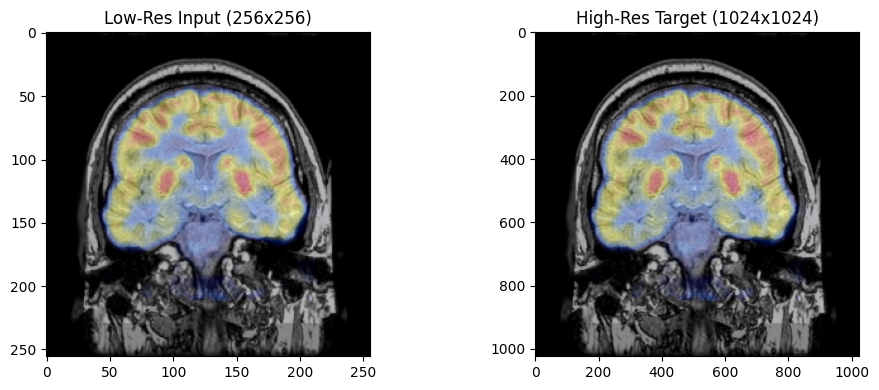

In [ ]:
# --- Sinusoidal Positional Embeddings for Timesteps ---
class SinusoidalPositionalEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# --- GroupNorm wrapper (unchanged) ---
class GroupNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        num_groups = min(8, channels)
        if num_groups == 0: num_groups = 1
        if channels % num_groups != 0:
            for i in range(num_groups, 0, -1):
                if channels % i == 0:
                    num_groups = i
                    break
            if num_groups == 0: num_groups = 1
        self.gn = nn.GroupNorm(num_groups=num_groups, num_channels=channels, eps=1e-5)

    def forward(self, x):
        return self.gn(x)

# --- ResBlock (fixed conditional feature handling) ---
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, conditional_channels=None):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        self.conv1 = nn.Sequential(
            GroupNorm(in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )

        self.conv2 = nn.Sequential(
            GroupNorm(out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
        )

        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.cond_proj = nn.Conv2d(conditional_channels, out_channels, 1) if conditional_channels is not None else None

    def forward(self, x, time_emb, conditional_features=None):
        h = self.conv1(x)
        h = h + self.mlp(time_emb)[:, :, None, None]

        if self.cond_proj is not None and conditional_features is not None:
            # --- Defensive fix for conditional_features ---
            if conditional_features.dim() == 5:
                conditional_features = conditional_features.squeeze(2)
            if h.shape[2] != conditional_features.shape[2] or h.shape[3] != conditional_features.shape[3]:
                conditional_features = F.interpolate(
                    conditional_features, size=(h.shape[2], h.shape[3]),
                    mode='bilinear', align_corners=False
                )
            proj_cond = self.cond_proj(conditional_features)
            if proj_cond.shape != h.shape:
                raise RuntimeError(f"Projected conditional features shape {proj_cond.shape} does not match h shape {h.shape}")
            h = h + proj_cond

        h = self.conv2(h)
        return h + self.residual_conv(x)

# --- AttentionBlock (unchanged) ---
class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.group_norm = GroupNorm(channels)
        self.proj_in = nn.Conv2d(channels, channels, 1)
        self.proj_out = nn.Conv2d(channels, channels, 1)

        self.num_heads = 8
        if channels < self.num_heads:
            self.num_heads = channels
        while channels % self.num_heads != 0 and self.num_heads > 1:
            self.num_heads -= 1
        if self.num_heads == 0: self.num_heads = 1

        self.head_dim = max(1, channels // self.num_heads)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        h = self.group_norm(x)
        h = self.proj_in(h)

        b, c, H, W = h.shape
        # recompute usable heads in case c changed
        current_num_heads = self.num_heads
        while c % current_num_heads != 0 and current_num_heads > 1:
            current_num_heads -= 1
        if current_num_heads == 0: current_num_heads = 1
        current_head_dim = c // current_num_heads

        h = h.view(b, current_num_heads, current_head_dim, H * W)
        q, k, v = h, h, h

        attn_scores = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale
        attn_weights = attn_scores.softmax(dim=-1)
        attn_output = torch.einsum('bhij,bhjd->bhid', attn_weights, v)

        attn_output = attn_output.view(b, c, H, W)
        h = self.proj_out(attn_output)
        return x + h

# --- DownBlock (unchanged, returns skip and downsampled output). ---
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, has_attn, conditional_channels=None, num_res_blocks=2):
        super().__init__()
        self.res_blocks = nn.ModuleList([
            ResBlock(in_channels if i == 0 else out_channels, out_channels, time_emb_dim, conditional_channels)
            for i in range(num_res_blocks)
        ])
        self.attn = AttentionBlock(out_channels) if has_attn else nn.Identity()
        self.downsample = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)

    def forward(self, x, time_emb, conditional_features=None):
        for res_block in self.res_blocks:
            x = res_block(x, time_emb, conditional_features)
        x_skipped = self.attn(x)
        return x_skipped, self.downsample(x_skipped)

# --- UpBlock (FIXED) ---
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, time_emb_dim, has_attn, conditional_channels=None, num_res_blocks=2):
        """
        in_channels: channels of the tensor coming into this up block (from previous stage)
        skip_channels: channels of the skip connection from the corresponding down block
        out_channels: desired output channels from this block
        """
        super().__init__()
        # Upsample from in_channels -> out_channels (spatially doubled, channels reduced to out_channels)
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)

        # After upsample, we will concatenate with skip (out_channels + skip_channels),
        # so the first ResBlock input channels = out_channels + skip_channels -> maps to out_channels
        self.res_blocks = nn.ModuleList([
            ResBlock(out_channels + skip_channels if i == 0 else out_channels, out_channels, time_emb_dim, conditional_channels)
            for i in range(num_res_blocks)
        ])
        self.attn = AttentionBlock(out_channels) if has_attn else nn.Identity()

    def forward(self, x, skip_connection, time_emb, conditional_features=None):
        x = self.upsample(x)  # now has out_channels channels
        # Ensure skip has the same spatial size
        if x.shape[2:] != skip_connection.shape[2:]:
            skip_connection = F.interpolate(skip_connection, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        x = torch.cat([x, skip_connection], dim=1)  # [B, out_channels + skip_channels, H, W]
        for res_block in self.res_blocks:
            x = res_block(x, time_emb, conditional_features)
        x = self.attn(x)
        return x

# --- U-Net (updated construction to pass skip_channels correctly) ---
class U_Net(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        image_channels = cfg.image_channels_hr
        time_emb_dim = cfg.base_channels * 4

        # Keep current time_mlp design but ensure dimensions line up:
        # Sinusoidal returns length "time_emb_dim // 2" in your original pattern,
        # then linear expands to time_emb_dim.
        self.time_mlp = nn.Sequential(
            SinusoidalPositionalEmbeddings(time_emb_dim // 2),
            nn.Linear(time_emb_dim // 2, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        self.initial_conv = nn.Conv2d(image_channels, cfg.base_channels, 3, padding=1)

        # Build downs and remember out_channels for each down (for skip_channels)
        self.downs = nn.ModuleList([])
        down_out_channels = []  # store skip channel sizes
        in_channels = cfg.base_channels
        current_res = cfg.image_size_hr
        for multiplier in cfg.channel_multipliers:
            out_channels = cfg.base_channels * multiplier
            has_attn = current_res in cfg.attn_resolutions
            # Use cfg.num_res_blocks as before
            self.downs.append(DownBlock(in_channels, out_channels, time_emb_dim, has_attn, cfg.conditional_channels, num_res_blocks=cfg.num_res_blocks))
            down_out_channels.append(out_channels)
            in_channels = out_channels
            current_res //= 2

        # Middle blocks
        self.middle_block1 = ResBlock(in_channels, in_channels, time_emb_dim, cfg.conditional_channels)
        self.middle_attn = AttentionBlock(in_channels)
        self.middle_block2 = ResBlock(in_channels, in_channels, time_emb_dim, cfg.conditional_channels)

        # Build ups using stored skip channels. We'll track prev_channels = channels coming from middle.
        self.ups = nn.ModuleList([])
        prev_channels = in_channels  # channels from middle (deepest)
        # iterate backwards over channel_multipliers and down_out_channels
        for i in reversed(range(len(cfg.channel_multipliers))):
            out_channels = cfg.base_channels * cfg.channel_multipliers[i]
            skip_channels = down_out_channels[i]
            has_attn = (out_channels * 2) in cfg.attn_resolutions if hasattr(cfg, 'attn_resolutions') else False
            # Create UpBlock(prev_channels, skip_channels, out_channels)
            self.ups.append(UpBlock(prev_channels, skip_channels, out_channels, time_emb_dim, has_attn, cfg.conditional_channels, num_res_blocks=cfg.num_res_blocks))
            prev_channels = out_channels  # next up will produce this many channels

        self.final_conv = nn.Sequential(
            GroupNorm(cfg.base_channels),
            nn.SiLU(),
            nn.Conv2d(cfg.base_channels, image_channels, 3, padding=1)
        )

    def forward(self, x, time, conditional_features):
        time_emb = self.time_mlp(time)  # shape [B, time_emb_dim]
        x = self.initial_conv(x)

        # Collect skip connections (the skip is the pre-downsample feature)
        skip_connections = []
        for down_block in self.downs:
            skip, x = down_block(x, time_emb, conditional_features)
            skip_connections.append(skip)

        # Middle
        x = self.middle_block1(x, time_emb, conditional_features)
        x = self.middle_attn(x)
        x = self.middle_block2(x, time_emb, conditional_features)

        # Ups: use skips in reverse order
        for up_block in self.ups:
            skip = skip_connections.pop()  # last added skip corresponds to current up
            x = up_block(x, skip, time_emb, conditional_features)

        return self.final_conv(x)

In [ ]:
# --- DDPM Scheduler ---
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

class DDPM_Scheduler:
    def __init__(self, cfg):
        self.cfg = cfg
        self.timesteps = cfg.timesteps
        self.device = cfg.device

        # Define beta schedule
        if cfg.beta_schedule == 'linear':
            betas = linear_beta_schedule(timesteps=cfg.timesteps, start=cfg.start_beta, end=cfg.end_beta).to(self.device)
        elif cfg.beta_schedule == 'cosine':
            betas = cosine_beta_schedule(timesteps=cfg.timesteps).to(self.device)
        else:
            raise ValueError(f"Unknown beta schedule: {cfg.beta_schedule}")

        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, axis=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0) # For calculations involving previous step

        # Register buffers (using setattr to mimic nn.Module's register_buffer for convenience)
        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev

        # calculations for diffusion q(x_t | x_0)
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

        # calculations for posterior q(x_t-1 | x_t, x_0)
        self.posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)
        
    def get_index_from_list(self, vals, t, x_shape):
        """
        Safely gathers values (e.g., betas, alphas) for a batch of timesteps.
        Returns shape: (batch_size, 1, 1, 1) to broadcast to img shape.
        """
        # Ensure both tensors are on the same device
        vals = vals.to(t.device)

        # Gather corresponding values for each timestep in the batch
        out = vals.gather(0, t)  # t shape: (B,)

        # Reshape for broadcasting (e.g. [B, 1, 1, 1] for 4D images)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))



    def q_sample(self, x_start, t, noise=None):
        """
        Noisy image at time t given x_0 (x_start)
        q(x_t | x_0) = N(x_t; sqrt(alpha_cumprod_t) * x_0, (1-alpha_cumprod_t) * I)
        """
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.get_index_from_list(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphas_cumprod_t = self.get_index_from_list(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    @torch.no_grad()
    def p_sample(self, model, x, t, conditional_features):
        """
        Sample from p(x_t-1 | x_t) using the predicted noise from the U-Net model.
        """
        beta_t = self.get_index_from_list(self.betas, t, x.shape)
        sqrt_one_minus_alphas_cumprod_t = self.get_index_from_list(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_recip_alphas_t = self.get_index_from_list(1. / self.alphas.sqrt(), t, x.shape)

        # Predict noise
        predicted_noise = model(x, t, conditional_features)

        # Use noise to predict x_0
        model_mean = sqrt_recip_alphas_t * (x - beta_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t)

        if t[0] == 0: # If at the first timestep (t=0), return the predicted x_0
            return model_mean
        else:
            posterior_variance_t = self.get_index_from_list(self.posterior_variance, t, x.shape)
            noise = torch.randn_like(x)
            return model_mean + torch.sqrt(posterior_variance_t) * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape, conditional_features):
        """
        Generates a sample image by iteratively denoisng from pure noise.
        """
        img = torch.randn(shape, device=self.device) * 0.5 # Start with pure noise, scaled
        
        # The conditional_features are already LR, and the U-Net's ResBlocks handle their upsampling internally.
        # So no explicit upsampling of conditional_features is needed here before passing to the U-Net.

        for i in tqdm(reversed(range(0, self.timesteps)), desc='sampling loop time step', total=self.timesteps):
            t = torch.full((shape[0],), i, device=self.device, dtype=torch.long)
            img = self.p_sample(model, img, t, conditional_features)
        
        # Ensure output is clamped to [-1, 1] range after sampling
        img = torch.clamp(img, -1., 1.)
        return img

    def p_losses(self, model, x_start, t, conditional_features, noise=None):
        """
        Calculates the diffusion loss given x_0, timestep t, and conditional features.
        """
        if noise is None:
            noise = torch.randn_like(x_start)

        x_noisy = self.q_sample(x_start=x_start, t=t, noise=noise)
        predicted_noise = model(x_noisy, t, conditional_features)

        if self.cfg.loss_type == 'l1':
            loss = F.l1_loss(noise, predicted_noise)
        elif self.cfg.loss_type == 'l2':
            loss = F.mse_loss(noise, predicted_noise)
        elif self.cfg.loss_type == 'huber':
            loss = F.huber_loss(noise, predicted_noise)
        else:
            raise ValueError(f"Unknown loss type: {self.cfg.loss_type}")

        return loss

print("DDPM Scheduler initialized.")
ddpm_scheduler = DDPM_Scheduler(cfg) # Initialize the scheduler

In [ ]:
# --- Diffusion Super-Resolution Model ---
class DiffusionSRModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tmfa = ASFE_Fusion_Model(cfg)
        self.unet = U_Net(cfg)

    def forward(self, x_noisy, timesteps, conditional_features=None,
                t1_lr=None, t2_lr=None, pet_lr=None):
        """
        Handles both direct and full-conditioning calls:
        - If conditional_features is provided, uses it directly.
        - Otherwise, computes it from the LR inputs (t1_lr, t2_lr, pet_lr).
        """
        timesteps = timesteps.to(x_noisy.device)

        # Compute conditional features if not provided
        if conditional_features is None:
            if t1_lr is None or t2_lr is None or pet_lr is None:
                raise ValueError("Need either conditional_features or all LR inputs.")
            conditional_features = self.tmfa(t1_lr, t2_lr, pet_lr)

        # 🔥 Upsample conditional features from LR → HR
        if conditional_features.shape[2:] != x_noisy.shape[2:]:
            conditional_features = F.interpolate(
                conditional_features,
                size=x_noisy.shape[2:],
                mode='bilinear',
                align_corners=False
            )

        # Predict noise with U-Net
        predicted_noise = self.unet(x_noisy, timesteps, conditional_features)
        return predicted_noise


# --- Initialize and test DiffusionSRModel (fixed) ---
print("\nInitializing DiffusionSRModel...")
diffusion_sr_model = DiffusionSRModel(cfg).to(cfg.device)
print(f"DiffusionSRModel Total Parameters: {sum(p.numel() for p in diffusion_sr_model.parameters()):,}")

try:
    # Grab a sample batch
    sample_batch = next(iter(train_dataloader))
    device = cfg.device

    # Move tensors to device
    t1_lr_batch = sample_batch['t1_lr'].to(device)
    t2_lr_batch = sample_batch['t2_lr'].to(device)
    pet_lr_batch = sample_batch['pet_lr'].to(device)
    gt_hr_batch = sample_batch['gt_hr'].to(device)

    # Random timesteps and noise
    dummy_timesteps = torch.randint(0, cfg.timesteps, (cfg.batch_size,), device=device).long()
    dummy_noise = torch.randn_like(gt_hr_batch).to(device)

    # Generate noisy HR image using q_sample
    dummy_x_hr_noisy = ddpm_scheduler.q_sample(
        x_start=gt_hr_batch,
        t=dummy_timesteps,
        noise=dummy_noise
    ).to(device)

    # Forward pass (shape-safe)
    with torch.no_grad():
        predicted_noise = diffusion_sr_model(
            x_noisy=dummy_x_hr_noisy,
            timesteps=dummy_timesteps,
            t1_lr=t1_lr_batch,
            t2_lr=t2_lr_batch,
            pet_lr=pet_lr_batch
        )

    # Validate output shape
    expected_shape = (cfg.batch_size, cfg.image_channels_hr, cfg.image_size_hr, cfg.image_size_hr)
    print(f"\nPredicted Noise Shape: {predicted_noise.shape}")
    assert predicted_noise.shape == expected_shape, f"Shape mismatch! Expected {expected_shape}, got {predicted_noise.shape}"
    print("✅ DiffusionSRModel forward test successful!")

except Exception as e:
    print(f"❌ Error during DiffusionSRModel test: {e}")

In [ ]:
# Import scikit-image metrics
from skimage.metrics import peak_signal_noise_ratio as psnr_skimage, structural_similarity as ssim_skimage


# --- PSNR Utility Function (using skimage) ---
def calculate_psnr(img1, img2, data_range=1.0):
    """
    Calculates PSNR (Peak Signal-to-Noise Ratio) between two images using skimage.
    Images are expected to be NumPy arrays of the same shape and type, in [0, data_range].
    
    Args:
        img1 (np.ndarray): First image.
        img2 (np.ndarray): Second image (ground truth).
        data_range (float): The dynamic range of the pixel values (e.g., 1.0 for [0,1] or 255.0 for [0,255]).
    Returns:
        float: The PSNR value.
    """
    if not img1.shape == img2.shape:
        raise ValueError("Input images must have the same dimensions for PSNR calculation.")
    
    # skimage's PSNR expects float images and calculates directly
    # Ensure images are float and within the correct data_range
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    return psnr_skimage(img1, img2, data_range=data_range)


# --- SSIM Utility Function (MODIFIED) ---
def calculate_ssim(img1, img2, data_range=1.0, multichannel=False):
    """
    Calculates SSIM (Structural Similarity Index Measure) between two images using skimage.
    Images are expected to be NumPy arrays of the same shape and type, in [0, data_range].

    Args:
        img1 (np.ndarray): First image.
        img2 (np.ndarray): Second image (ground truth).
        data_range (float): The dynamic range of the pixel values (e.g., 1.0 for [0,1] or 255.0 for [0,255]).
        multichannel (bool): If True, img1 and img2 are treated as multichannel images
                             (e.g., RGB). The last dimension is assumed to be the channel dimension.
                             For grayscale images (2D or 3D with 1 channel), set to False.
    Returns:
        float: The SSIM value.
    """
    if not img1.shape == img2.shape:
        raise ValueError("Input images must have the same dimensions for SSIM calculation.")
    
    # Ensure images are float and within the correct data_range
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    # --- Start of Modifications ---
    
    # Determine minimum image dimension for win_size
    # win_size must be odd and <= min(H, W)
    # The spatial dimensions are always the first two (H, W) for both grayscale and multichannel images
    min_spatial_dim = min(img1.shape[0], img1.shape[1])
    
    # Default win_size is 7, but adjust if image is smaller than 7x7
    win_size = min(7, min_spatial_dim) 
    if win_size % 2 == 0: # Ensure win_size is odd
        win_size -= 1
    if win_size < 3: # Smallest acceptable win_size is 3
        win_size = 3 # If the image is smaller than 3x3, SSIM might not be meaningful anyway.
    
    # Pass channel_axis explicitly if multichannel is True
    if multichannel:
        # For images in (H, W, C) format, the channel_axis is 2 (0-indexed)
        # This is the format output by your `denormalize_img_to_numpy` for multichannel.
        return ssim_skimage(img1, img2, data_range=data_range, win_size=win_size, channel_axis=2)
    else:
        # For grayscale images (2D: HxW, or 3D: HxWx1), no channel_axis is needed.
        # win_size still applies.
        return ssim_skimage(img1, img2, data_range=data_range, win_size=win_size)

# --- Denormalization Function (unchanged) ---
def denormalize_img_to_numpy(tensor):
    """
    Converts a normalized PyTorch tensor from [-1, 1] to a denormalized NumPy array in [0, 1].diffusion_sr_model
    Expected input shape: (C, H, W).
    Returns (H, W) for 1-channel, or (H, W, C) for 3/4-channel.
    """
    img_01 = ((tensor + 1) / 2).clamp(0, 1).cpu()

    if img_01.ndim == 3: # (C, H, W)
        if img_01.shape[0] == 1: # Grayscale image
            return img_01[0].numpy() # Return (H, W)
        elif img_01.shape[0] in [3, 4]: # RGB or RGBA image
            return img_01.permute(1, 2, 0).numpy() # Return (H, W, C)
        else: # For other multi-channel inputs, return as (H, W, C)
            # print(f"Warning: denormalize_img_to_numpy received {img_01.shape[0]} channels. Returning as (H, W, C).")
            return img_01.permute(1, 2, 0).numpy()
    else:
        raise ValueError(f"Unsupported tensor dimensions for denormalize_img_to_numpy: {img_01.ndim}. Expected 3 (C, H, W).")
    
# --- Optimizer and Loss Function ---
# Ensure cfg.learning_rate is defined in your config
optimizer = torch.optim.AdamW(diffusion_sr_model.parameters(), lr=cfg.learning_rate)

Epoch 1/35 | Loss: 1.0325 | PSNR: 5.67 | SSIM: 0.0022
Epoch 2/35 | Loss: 0.8586 | PSNR: 6.31 | SSIM: 0.0029
Epoch 3/35 | Loss: 0.7344 | PSNR: 6.52 | SSIM: 0.0031
Epoch 4/35 | Loss: 0.6518 | PSNR: 6.66 | SSIM: 0.0031
Epoch 5/35 | Loss: 0.5721 | PSNR: 6.77 | SSIM: 0.0035


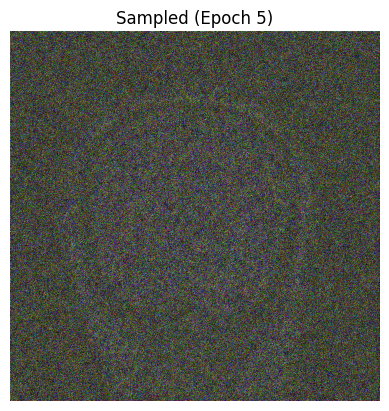

Epoch 6/35 | Loss: 0.5404 | PSNR: 7.00 | SSIM: 0.0039
Epoch 7/35 | Loss: 0.5023 | PSNR: 6.91 | SSIM: 0.0035
Epoch 8/35 | Loss: 0.4674 | PSNR: 7.04 | SSIM: 0.0037
Epoch 9/35 | Loss: 0.4249 | PSNR: 7.09 | SSIM: 0.0042
Epoch 10/35 | Loss: 0.3946 | PSNR: 7.09 | SSIM: 0.0045


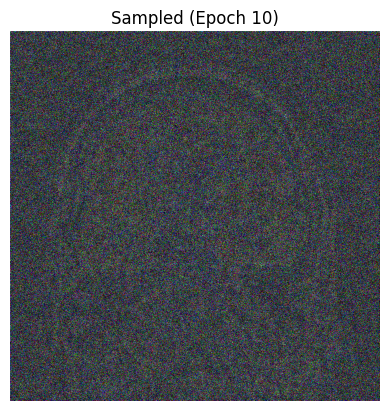

In [ ]:
# --- Training Loop ---
print("\nStarting Training...")
global_step = 0
training_losses = []
metrics_history = [] # To store PSNR and SSIM values per epoch

# Get one sample batch for consistent PSNR/SSIM evaluation across epochs
# (Better to use a separate validation dataloader for this, but for simplicity, we'll use a sample from training)
try:
    eval_batch = next(iter(train_dataloader))
except StopIteration:
    print("Dataloader is empty, cannot get evaluation batch.")
    eval_batch = None # Handle case where dataloader is empty

for epoch in range(cfg.num_epochs):
    diffusion_sr_model.train() # Set model to training mode
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}")
    for batch_idx, batch in enumerate(pbar):
        optimizer.zero_grad()

        # Move batch to device
        t1_lr = batch['t1_lr'].to(cfg.device)
        t2_lr = batch['t2_lr'].to(cfg.device)
        pet_lr = batch['pet_lr'].to(cfg.device)
        gt_hr = batch['gt_hr'].to(cfg.device)

        # Sample random timesteps
        timesteps = torch.randint(0, cfg.timesteps, (gt_hr.shape[0],), device=cfg.device).long()

        # Compute conditional features for the current batch
        conditional_features = diffusion_sr_model.tmfa(t1_lr, t2_lr, pet_lr)

        # Compute loss
        loss = ddpm_scheduler.p_losses(
            model=diffusion_sr_model.unet, # Pass only the U-Net part to p_losses
            x_start=gt_hr,
            t=timesteps,
            conditional_features=conditional_features
        )

        # Backprop
        loss.backward()
        optimizer.step()

        global_step += 1
        training_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        if global_step % cfg.log_interval == 0:
            avg_loss = sum(training_losses[-cfg.log_interval:]) / cfg.log_interval
            # print(f"Step {global_step:06d} | Avg Loss: {avg_loss:.4f}") # Uncomment if you want step-level logging


    print(f"Epoch {epoch+1} finished. Training Loss: {loss.item():.4f}")

    # --- PSNR and SSIM Evaluation at end of epoch ---
    if (epoch + 1) % cfg.eval_interval == 0 and eval_batch is not None:
        diffusion_sr_model.eval() # Set model to evaluation mode
        
        with torch.no_grad():
            # Prepare evaluation inputs (use the same `eval_batch` obtained earlier)
            eval_t1_lr = eval_batch['t1_lr'][0:1].to(cfg.device) 
            eval_t2_lr = eval_batch['t2_lr'][0:1].to(cfg.device)
            eval_pet_lr = eval_batch['pet_lr'][0:1].to(cfg.device)
            eval_gt_hr = eval_batch['gt_hr'][0:1].to(cfg.device) # Full HR GT (5 channels)

            # Get conditional features for evaluation sample
            eval_conditional_features = diffusion_sr_model.tmfa(eval_t1_lr, eval_t2_lr, eval_pet_lr)

            # Generate SR image for evaluation
            sr_image_shape = (1, cfg.image_channels_hr, cfg.image_size_hr, cfg.image_size_hr)
            generated_sr_full_channels = ddpm_scheduler.p_sample_loop(
                model=diffusion_sr_model.unet,
                shape=sr_image_shape,
                conditional_features=eval_conditional_features
            )

            # Denormalize generated SR and Ground Truth for PSNR/SSIM
            sr_t1_np = denormalize_img_to_numpy(generated_sr_full_channels[0, 0].unsqueeze(0)) # T1 channel
            sr_t2_np = denormalize_img_to_numpy(generated_sr_full_channels[0, 1].unsqueeze(0)) # T2 channel
            sr_pet_rgb_np = denormalize_img_to_numpy(generated_sr_full_channels[0, 2:5]) # PET RGB

            gt_t1_np = denormalize_img_to_numpy(eval_gt_hr[0, 0].unsqueeze(0))
            gt_t2_np = denormalize_img_to_numpy(eval_gt_hr[0, 1].unsqueeze(0))
            gt_pet_rgb_np = denormalize_img_to_numpy(eval_gt_hr[0, 2:5])

            # Calculate PSNR for each component using skimage
            psnr_t1 = calculate_psnr(sr_t1_np, gt_t1_np)
            psnr_t2 = calculate_psnr(sr_t2_np, gt_t2_np)
            psnr_pet_rgb = calculate_psnr(sr_pet_rgb_np, gt_pet_rgb_np)
            
            # Calculate SSIM for each component using skimage
            # For grayscale (T1, T2), multichannel=False
            # For RGB (PET), multichannel=True
            ssim_t1 = calculate_ssim(sr_t1_np, gt_t1_np, multichannel=False)
            ssim_t2 = calculate_ssim(sr_t2_np, gt_t2_np, multichannel=False)
            ssim_pet_rgb = calculate_ssim(sr_pet_rgb_np, gt_pet_rgb_np, multichannel=True)
            
            print(f"Epoch {epoch+1} | "
                  f"PSNR - T1: {psnr_t1:.2f} dB, T2: {psnr_t2:.2f} dB, PET (RGB): {psnr_pet_rgb:.2f} dB | "
                  f"SSIM - T1: {ssim_t1:.4f}, T2: {ssim_t2:.4f}, PET (RGB): {ssim_pet_rgb:.4f}")
            
            metrics_history.append({
                'epoch': epoch+1,
                'psnr_t1': psnr_t1, 'psnr_t2': psnr_t2, 'psnr_pet_rgb': psnr_pet_rgb,
                'ssim_t1': ssim_t1, 'ssim_t2': ssim_t2, 'ssim_pet_rgb': ssim_pet_rgb
            })

        diffusion_sr_model.train() # Set model back to training mode


    # Save model checkpoint
    if (epoch + 1) % cfg.save_interval == 0:
        torch.save(diffusion_sr_model.state_dict(), cfg.model_save_path)
        print(f"Model saved to {cfg.model_save_path} after epoch {epoch+1}")

print("\nTraining complete!")

# Optional: You can print the history of metrics values at the end
print("\nMetrics History:")
for entry in metrics_history:
    print(f"Epoch {entry['epoch']}: "
          f"PSNR (T1={entry['psnr_t1']:.2f}, T2={entry['psnr_t2']:.2f}, PET_RGB={entry['psnr_pet_rgb']:.2f}) | "
          f"SSIM (T1={entry['ssim_t1']:.4f}, T2={entry['ssim_t2']:.4f}, PET_RGB={entry['ssim_pet_rgb']:.4f})")

In [ ]:
# Assuming torch is already imported and available from your context

print("\nStarting Inference...")

# Load the best model (or the last saved one)
try:
    diffusion_sr_model.load_state_dict(torch.load(cfg.model_save_path, map_location=cfg.device))
    print(f"Model loaded from {cfg.model_save_path}")
except FileNotFoundError:
    print(f"No saved model found at {cfg.model_save_path}. Please ensure a model is trained or available.")
except Exception as e:
    print(f"Error loading model: {e}. Using a dummy model for inference output demonstration.")

diffusion_sr_model.eval() # Set model to evaluation mode

# Get a batch of data for inference (can use the same dataloader)
# For demo, using the dummy sample_batch
# sample_batch = next(iter(dataloader)) # Get another random batch for demonstration

# t1_lr_input and t2_lr_input are 1-channel, pet_lr_input_full is 3-channel RGB
t1_lr_input = sample_batch['t1_lr'][0:1].to(cfg.device) 
t2_lr_input = sample_batch['t2_lr'][0:1].to(cfg.device)
pet_lr_input_full = sample_batch['pet_lr'][0:1].to(cfg.device) # This is now RGB (3 channels)

# The ground truth for the model: Full HR GT (5 channels: T1, T2, PET_R, PET_G, PET_B)
gt_hr_full_channels = sample_batch['gt_hr'][0:1].to(cfg.device)

# 1. Get conditional features from TMFA for the LR input
with torch.no_grad():
    conditional_features_for_sampling = diffusion_sr_model.tmfa(t1_lr_input, t2_lr_input, pet_lr_input_full)

# 2. Generate SR image using the DDPM sampler
sr_image_shape = (1, cfg.image_channels_hr, cfg.image_size_hr, cfg.image_size_hr) # (batch_size=1, C=5, H, W)

with torch.no_grad():
    generated_sr_full_channels = ddpm_scheduler.p_sample_loop(
        model=diffusion_sr_model.unet, # Pass only the U-Net for sampling
        shape=sr_image_shape,
        conditional_features=conditional_features_for_sampling
    )

print("Inference complete!")

# --- Visualization Utility Functions (Modified) ---

def denormalize_img_to_numpy(tensor):
    """
    Converts a normalized PyTorch tensor from [-1, 1] to a denormalized NumPy array in [0, 1].
    Expected input shape: (C, H, W).
    Returns (H, W) for 1-channel, or (H, W, C) for 3/4-channel.
    """
    img_01 = ((tensor + 1) / 2).clamp(0, 1).cpu()

    if img_01.ndim == 3: # (C, H, W)
        if img_01.shape[0] == 1: # Grayscale image
            return img_01[0].numpy() # Return (H, W)
        elif img_01.shape[0] in [3, 4]: # RGB or RGBA image
            return img_01.permute(1, 2, 0).numpy() # Return (H, W, C)
        else: # For other multi-channel inputs, return as (H, W, C)
            print(f"Warning: denormalize_img_to_numpy received {img_01.shape[0]} channels. Returning as (H, W, C).")
            return img_01.permute(1, 2, 0).numpy()
    else:
        raise ValueError(f"Unsupported tensor dimensions for denormalize_img_to_numpy: {img_01.ndim}. Expected 3 (C, H, W).")


# --- MODIFIED FUNCTION FOR T1, T2, PET FUSION ---
def create_t1_t2_pet_fusion_display_rgb(t1_np_grayscale, t2_np_grayscale, pet_np_rgb, 
                                        mri_blend_weight_t1=0.7, pet_alpha=0.5):
    """
    Creates a fusion image from grayscale T1, grayscale T2, and RGB PET,
    retaining grayscale for MRIs and original RGB for PET.

    Fusion Strategy:
    1. Create a base MRI image by blending T1 and T2 (resulting in grayscale).
    2. Convert this grayscale MRI base into a 3-channel RGB image (where R=G=B).
    3. Directly overlay the original RGB PET onto this 3-channel grayscale MRI base.
    
    Args:
        t1_np_grayscale (np.ndarray): Grayscale T1 image (H, W) or (H, W, 1), in [0, 1].
        t2_np_grayscale (np.ndarray): Grayscale T2 image (H, W) or (H, W, 1), in [0, 1].
        pet_np_rgb (np.ndarray): PET RGB image (H, W, 3), in [0, 1]. This must be 3-channel RGB.
                                 (Ensure this is truly the original RGB PET data if you want to preserve its colors).
        mri_blend_weight_t1 (float): Weight for T1 when blending with T2 (0.0 to 1.0).
                                     (1 - mri_blend_weight_t1) is the weight for T2.
        pet_alpha (float): Transparency of the PET overlay (0.0 to 1.0).

    Returns:
        np.ndarray: The fused image as a NumPy array (H, W, 3) in RGB format, [0, 1] float.
    """
    # Ensure MRI inputs are 2D grayscale
    if t1_np_grayscale.ndim == 3 and t1_np_grayscale.shape[2] == 1:
        t1_np_grayscale = t1_np_grayscale[:,:,0]
    if t2_np_grayscale.ndim == 3 and t2_np_grayscale.shape[2] == 1:
        t2_np_grayscale = t2_np_grayscale[:,:,0]
        
    # Ensure PET input is 3D RGB
    if not (pet_np_rgb.ndim == 3 and pet_np_rgb.shape[2] == 3):
        raise ValueError("pet_np_rgb must be a 3-channel (H, W, 3) image for this fusion strategy to preserve RGB PET.")


    # 1. Create a blended MRI base (T1 and T2) in grayscale
    mri_base_grayscale = (t1_np_grayscale * mri_blend_weight_t1 + 
                          t2_np_grayscale * (1 - mri_blend_weight_t1)).clip(0, 1)

    # 2. Convert grayscale MRI base to 3-channel RGB (R=G=B)
    mri_base_rgb = np.stack([mri_base_grayscale, mri_base_grayscale, mri_base_grayscale], axis=-1)

    # 3. Directly overlay the original RGB PET onto the 3-channel grayscale MRI base
    # Use cv2.addWeighted for blending (expects 0-255 uint8, BGR)
    mri_base_bgr_uint8 = (mri_base_rgb * 255).astype(np.uint8)[:, :, ::-1] # RGB to BGR
    pet_original_bgr_uint8 = (pet_np_rgb * 255).astype(np.uint8)[:, :, ::-1] # Original PET RGB to BGR

    fused_bgr_image_uint8 = cv2.addWeighted(mri_base_bgr_uint8, 1 - pet_alpha, pet_original_bgr_uint8, pet_alpha, 0)
    
    # Convert back to RGB float [0, 1] for Matplotlib display
    fused_rgb_image_float = fused_bgr_image_uint8[:, :, ::-1].astype(np.float32) / 255.0

    return fused_rgb_image_float


# --- Prepare images for display ---

# LR inputs
t1_lr_display = denormalize_img_to_numpy(t1_lr_input[0,0].unsqueeze(0)) 
t2_lr_display = denormalize_img_to_numpy(t2_lr_input[0,0].unsqueeze(0)) 
pet_lr_rgb_display = denormalize_img_to_numpy(pet_lr_input_full[0]) # PET-LR is RGB (3 channels)


# --- Prepare Ground Truth for Fusion Display (5 channels: T1, T2, PET_R, PET_G, PET_B) ---
gt_hr_t1_channel = denormalize_img_to_numpy(gt_hr_full_channels[0, 0].unsqueeze(0)) # 0th channel is T1
gt_hr_t2_channel = denormalize_img_to_numpy(gt_hr_full_channels[0, 1].unsqueeze(0)) # 1st channel is T2
# Reconstruct PET RGB from channels 2, 3, 4. This is crucial to get the *original* RGB for PET.
gt_hr_pet_original_rgb = denormalize_img_to_numpy(gt_hr_full_channels[0, 2:5]) 


# Create T1-T2-PET HR Fusion using the MODIFIED function
gt_fused_t1_t2_pet_rgb = create_t1_t2_pet_fusion_display_rgb( # Call the modified function here
    gt_hr_t1_channel,
    gt_hr_t2_channel,
    gt_hr_pet_original_rgb, # Pass the original PET RGB directly
    mri_blend_weight_t1=0.7, # Emphasize T1 for structural base
    pet_alpha=0.6 # Adjust PET transparency
)


# --- Prepare Generated SR Output for Fusion Display (5 channels: T1, T2, PET_R, PET_G, PET_B) ---
sr_t1_channel = denormalize_img_to_numpy(generated_sr_full_channels[0, 0].unsqueeze(0)) # 0th channel is T1 from SR
sr_t2_channel = denormalize_img_to_numpy(generated_sr_full_channels[0, 1].unsqueeze(0)) # 1st channel is T2 from SR
# Reconstruct PET RGB from channels 2, 3, 4
sr_pet_original_rgb = denormalize_img_to_numpy(generated_sr_full_channels[0, 2:5])

# Create T1-T2-PET SR Fusion using the MODIFIED function
generated_fused_t1_t2_pet_rgb = create_t1_t2_pet_fusion_display_rgb( # Call the modified function here
    sr_t1_channel,
    sr_t2_channel,
    sr_pet_original_rgb,
    mri_blend_weight_t1=0.7,
    pet_alpha=0.6
)


# --- Plotting ---
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

fig, axes = plt.subplots(1, 5, figsize=(25, 6)) 
fig.suptitle("Super-Resolution Results with T1-T2-PET Fusion (Retaining Grayscale MRI & RGB PET)", fontsize=16) # Changed title

axes[0].imshow(t1_lr_display, cmap='gray')
axes[0].set_title(f"T1-LR ({cfg.image_size_lr})")
axes[0].axis('off')

axes[1].imshow(t2_lr_display, cmap='gray')
axes[1].set_title(f"T2-LR ({cfg.image_size_lr})")
axes[1].axis('off')

axes[2].imshow(pet_lr_rgb_display) # Display RGB PET directly
axes[2].set_title(f"PET-LR (RGB) ({cfg.image_size_lr})") 
axes[2].axis('off')

# Display the FUSED HR GT (Now directly RGB [0,1])
# Removed cv2.cvtColor(..., cv2.COLOR_YCrCb2RGB) as the function now returns direct RGB
axes[3].imshow(gt_fused_t1_t2_pet_rgb) 
axes[3].set_title(f"Fused HR GT (T1+T2+PET) (RGB) ({cfg.image_size_hr})")
axes[3].axis('off')

# Display the FUSED Generated SR (Now directly RGB [0,1])
# Removed cv2.cvtColor(..., cv2.COLOR_YCrCb2RGB) as the function now returns direct RGB
axes[4].imshow(generated_fused_t1_t2_pet_rgb) 
axes[4].set_title(f"Generated SR (T1+T2+PET) (RGB) ({cfg.image_size_hr})")
axes[4].axis('off')

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()